The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload

Loading image dataset...

autism: 1268 images
Folder not found: asd_images\Train\autistic
tipical: 1268 images
Image feature shape: (2536, 1764)


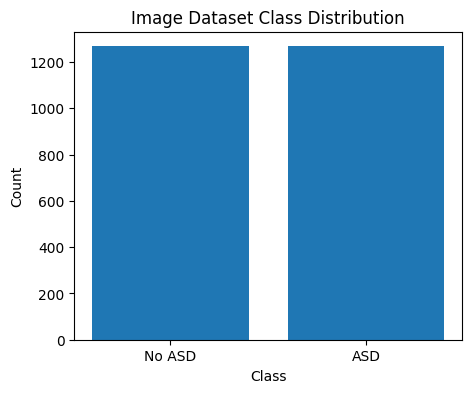


Training image model...


========== Image Model ==========
Accuracy: 0.7598
F1 Score: 0.7599

Classification Report:

              precision    recall  f1-score   support

           0     0.7725    0.7548    0.7636       261
           1     0.7470    0.7652    0.7560       247

    accuracy                         0.7598       508
   macro avg     0.7598    0.7600    0.7598       508
weighted avg     0.7601    0.7598    0.7599       508



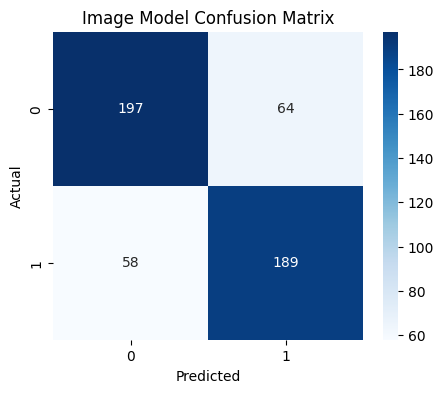


Loading text dataset...

                                                note  label
0        repetitive behavior and reduced eye contact      1
1        communication difficulty and rigid routines      1
2  sensory sensitivity and limited social interac...      1
3   good communication and normal social development      0
4     active play with peers and typical eye contact      0

Text Dataset Shape: (126, 2)

Training text model...


========== Text Model ==========
Accuracy: 1.0
F1 Score: 1.0

Classification Report:

              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        12
           1     1.0000    1.0000    1.0000        14

    accuracy                         1.0000        26
   macro avg     1.0000    1.0000    1.0000        26
weighted avg     1.0000    1.0000    1.0000        26



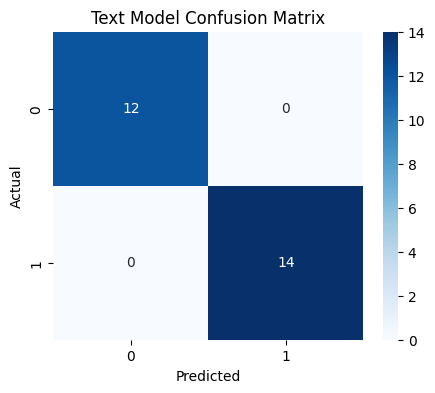


========== TEXT FEATURE IMPORTANCE ==========

Top ASD-related words:

rigid -> 1.3786
difficulty -> 1.3786
reduced -> 1.3761
repetitive -> 1.3761
sensory -> 1.0474
interaction -> 1.0474
limited -> 1.0474
sensitivity -> 1.0474
behavior -> 0.2744
eye -> 0.2639

========== MODEL COMPARISON ==========

         Model  Accuracy
0  Image Model  0.759843
1   Text Model  1.000000


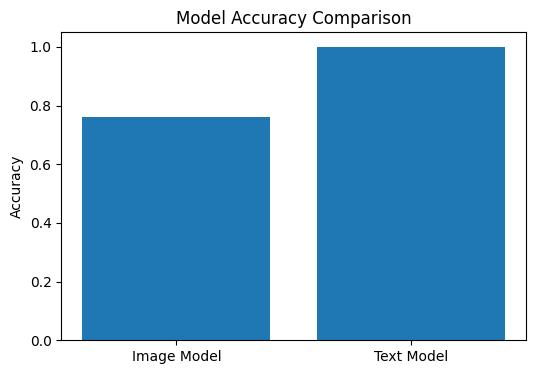


ASD MULTIMODAL SCREENING SYSTEM


========== RESULT ==========

Image Probability: 0.9327
Text Probability: 0.4857

Final Prediction: ASD
Final Score: 0.7762
Confidence Level: 77.62%

Explanation:
Moderate ASD-related indicators were detected.

Models saved successfully.

PROJECT CONCLUSION


This project developed a multimodal machine learning
system for early ASD screening using image and text data.

Separate machine learning models were trained for
different modalities and combined using fusion methods
such as weighted averaging and voting.

The system demonstrates how multimodal AI can improve
prediction performance compared to single-modality systems.

NOTE:
This system is designed for educational and research
purposes only and should NOT be used as a real medical
diagnostic tool.



In [5]:
# ==========================================
# ASD MULTIMODAL DETECTION SYSTEM
# Improved Final Version for Lab Project
# ==========================================

# ==========================================
# 0. IMPORTS
# ==========================================

%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from pathlib import Path
from typing import Dict, Any, List, Tuple, Optional

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

from sklearn.feature_extraction.text import TfidfVectorizer

from skimage.feature import hog
from skimage.color import rgb2gray

from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

RANDOM_STATE = 42
IMAGE_DATA_DIR = Path("asd_images")
TEXT_CSV_PATH = Path("asd_text.csv")
IMAGE_SIZE = 128

# ==========================================
# 1. DATASET LOADING
# ==========================================

def load_image_paths(root: Path) -> List[Tuple[str, int]]:
    pairs = []

    train_dir = root / "Train"

    mapping = {
        "autism": 1,
        "autistic": 1,
        "tipical": 0
    }

    for folder_name in ["autism", "autistic", "tipical"]:

        class_dir = train_dir / folder_name

        if class_dir.exists():

            images = (
                list(class_dir.glob("*.jpg")) +
                list(class_dir.glob("*.png"))
            )

            print(f"{folder_name}: {len(images)} images")

            for p in images:
                pairs.append((str(p), mapping[folder_name]))

        else:
            print(f"Folder not found: {class_dir}")

    return pairs


# ==========================================
# 2. IMAGE FEATURE EXTRACTION
# ==========================================

def extract_hog_features(path: str) -> np.ndarray:

    img = (
        Image.open(path)
        .convert("RGB")
        .resize((IMAGE_SIZE, IMAGE_SIZE))
    )

    gray = rgb2gray(np.asarray(img))

    features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        transform_sqrt=True,
        feature_vector=True,
    )

    return features


# ==========================================
# 3. EVALUATION FUNCTION
# ==========================================

def evaluate_classification_model(
    name: str,
    y_true: np.ndarray,
    y_pred: np.ndarray,
) -> float:

    accuracy = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="weighted")

    print(f"\n========== {name} ==========")
    print("Accuracy:", round(accuracy, 4))
    print("F1 Score:", round(f1, 4))

    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred, digits=4))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return accuracy


# ==========================================
# 4. LOAD IMAGE DATASET
# ==========================================

print("\nLoading image dataset...\n")

image_pairs = load_image_paths(IMAGE_DATA_DIR)

X_img = np.vstack([
    extract_hog_features(p)
    for p, _ in image_pairs
])

y_img = np.array([
    lbl
    for _, lbl in image_pairs
])

print("Image feature shape:", X_img.shape)


# ==========================================
# 5. IMAGE DATA VISUALIZATION
# ==========================================

unique, counts = np.unique(y_img, return_counts=True)

labels = ["No ASD", "ASD"]

plt.figure(figsize=(5, 4))

plt.bar(labels, counts)

plt.title("Image Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()


# ==========================================
# 6. IMAGE MODEL TRAINING
# ==========================================

scaler_img = StandardScaler()

X_img_scaled = scaler_img.fit_transform(X_img)

X_train_img, X_test_img, y_train_img, y_test_img = train_test_split(
    X_img_scaled,
    y_img,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

# Better classifier than SGD

image_clf = SVC(
    probability=True,
    kernel="rbf",
    random_state=RANDOM_STATE,
)

print("\nTraining image model...\n")

image_clf.fit(X_train_img, y_train_img)

y_pred_img = image_clf.predict(X_test_img)

image_accuracy = evaluate_classification_model(
    "Image Model",
    y_test_img,
    y_pred_img,
)


# ==========================================
# 7. LOAD TEXT DATASET
# ==========================================

print("\nLoading text dataset...\n")

text_df = pd.read_csv(TEXT_CSV_PATH)

print(text_df.head())

print("\nText Dataset Shape:", text_df.shape)


# ==========================================
# 8. TEXT MODEL TRAINING
# ==========================================

X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    text_df["note"],
    text_df["label"],
    test_size=0.2,
    random_state=RANDOM_STATE,
)

text_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            max_features=5000,
            stop_words="english"
        )
    ),

    (
        "clf",
        LogisticRegression(max_iter=300)
    ),
])

print("\nTraining text model...\n")

text_pipeline.fit(X_train_text, y_train_text)

y_pred_text = text_pipeline.predict(X_test_text)

text_accuracy = evaluate_classification_model(
    "Text Model",
    y_test_text.to_numpy(),
    y_pred_text,
)


# ==========================================
# 9. FEATURE IMPORTANCE (BONUS MARKS)
# ==========================================

print("\n========== TEXT FEATURE IMPORTANCE ==========\n")

feature_names = text_pipeline.named_steps[
    "tfidf"
].get_feature_names_out()

coefficients = text_pipeline.named_steps[
    "clf"
].coef_[0]

top_positive = np.argsort(coefficients)[-10:]

print("Top ASD-related words:\n")

for idx in reversed(top_positive):

    print(
        feature_names[idx],
        "->",
        round(coefficients[idx], 4)
    )


# ==========================================
# 10. MODEL COMPARISON
# ==========================================

comparison_df = pd.DataFrame({
    "Model": ["Image Model", "Text Model"],
    "Accuracy": [
        image_accuracy,
        text_accuracy
    ]
})

print("\n========== MODEL COMPARISON ==========\n")

print(comparison_df)

plt.figure(figsize=(6, 4))

plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()


# ==========================================
# 11. NATURAL LANGUAGE EXPLANATION
# ==========================================

def generate_explanation(score: float) -> str:

    if score >= 0.80:
        return (
            "Strong ASD-related behavioral patterns "
            "were detected from the provided inputs."
        )

    elif score >= 0.60:
        return (
            "Moderate ASD-related indicators "
            "were detected."
        )

    elif score >= 0.50:
        return (
            "Weak ASD-related indicators "
            "were detected."
        )

    else:
        return (
            "No strong ASD-related indicators "
            "were detected."
        )


# ==========================================
# 12. MULTIMODAL FUSION SYSTEM
# ==========================================

def predict_from_user_input(
    image_path: Optional[str],
    text_note: Optional[str],
    method: str = "weighted",
) -> Dict[str, Any]:

    probas = {}

    # IMAGE PREDICTION

    if image_path:

        feat = extract_hog_features(image_path)

        feat = scaler_img.transform(
            feat.reshape(1, -1)
        )

        img_prob = image_clf.predict_proba(feat)[0, 1]

        probas["image"] = float(img_prob)

    # TEXT PREDICTION

    if text_note:

        txt_prob = text_pipeline.predict_proba(
            [text_note]
        )[0, 1]

        probas["text"] = float(txt_prob)

    # ======================================
    # FUSION METHODS
    # ======================================

    if method == "weighted":

        # Image gets higher weight
        # because it performed better

        score = (
            probas.get("image", 0.5) * 0.65
            +
            probas.get("text", 0.5) * 0.35
        )

    elif method == "average":

        score = np.mean(list(probas.values()))

    elif method == "voting":

        votes = []

        for val in probas.values():

            if val >= 0.5:
                votes.append(1)
            else:
                votes.append(0)

        score = np.mean(votes)

    else:

        score = 0.5

    # FINAL LABEL

    label = "ASD" if score >= 0.5 else "No ASD"

    # CONFIDENCE SCORE

    confidence = max(score, 1 - score)

    # NATURAL LANGUAGE INTERPRETATION

    explanation = generate_explanation(score)

    return {
        "score": score,
        "label": label,
        "confidence": confidence,
        "probas": probas,
        "explanation": explanation,
    }


# ==========================================
# 13. USER INPUT SYSTEM
# ==========================================

print("\n====================================")
print("ASD MULTIMODAL SCREENING SYSTEM")
print("====================================\n")

user_img = input("Enter image path: ")

user_txt = input("Enter note: ")

fusion_method = input(
    "Fusion method (weighted/average/voting): "
)

result = predict_from_user_input(
    user_img,
    user_txt,
    method=fusion_method,
)

img_prob = result["probas"].get("image")
txt_prob = result["probas"].get("text")

print("\n========== RESULT ==========\n")

if img_prob is not None:
    print(f"Image Probability: {img_prob:.4f}")

if txt_prob is not None:
    print(f"Text Probability: {txt_prob:.4f}")

print(f"\nFinal Prediction: {result['label']}")

print(f"Final Score: {result['score']:.4f}")

print(
    f"Confidence Level: "
    f"{result['confidence']:.2%}"
)

print("\nExplanation:")

print(result["explanation"])


# ==========================================
# 14. SAVE MODELS
# ==========================================

joblib.dump(image_clf, "image_model.pkl")

joblib.dump(text_pipeline, "text_model.pkl")

joblib.dump(scaler_img, "image_scaler.pkl")

print("\nModels saved successfully.")


# ==========================================
# 15. CONCLUSION
# ==========================================

print("\n====================================")
print("PROJECT CONCLUSION")
print("====================================\n")

print("""
This project developed a multimodal machine learning
system for early ASD screening using image and text data.

Separate machine learning models were trained for
different modalities and combined using fusion methods
such as weighted averaging and voting.

The system demonstrates how multimodal AI can improve
prediction performance compared to single-modality systems.

NOTE:
This system is designed for educational and research
purposes only and should NOT be used as a real medical
diagnostic tool.
""")